In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/DEEP_LEARNING/data/AQI_prediction_data/final_dataset.csv'
)

df.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB


In [4]:
df.describe()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
count,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000
mean,15.729637,6.522930,2022.501027,0.189596,4.000684,90.774538,218.219261,37.184921,20.104921,1.025832,36.338871,202.210815
std,8.803105,3.449884,1.118723,0.392116,2.001883,71.650579,129.297734,35.225327,16.543659,0.608305,18.951204,107.801076
min,1.000000,1.000000,2021.000000,0.000000,1.000000,0.050000,9.690000,2.160000,1.210000,0.270000,2.700000,19.000000
25%,8.000000,4.000000,2022.000000,0.000000,2.000000,41.280000,115.110000,17.280000,7.710000,0.610000,24.100000,108.000000
50%,16.000000,7.000000,2023.000000,0.000000,4.000000,72.060000,199.800000,30.490000,15.430000,0.850000,32.470000,189.000000
75%,23.000000,10.000000,2024.000000,0.000000,6.000000,118.500000,297.750000,45.010000,26.620000,1.240000,45.730000,284.000000
max,31.000000,12.000000,2024.000000,1.000000,7.000000,1000.000000,1000.000000,433.980000,113.400000,4.700000,115.870000,500.000000


In [5]:
df.isnull().sum()

,0
Date,0
Month,0
Year,0
Holidays_Count,0
Days,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0


In [6]:
df.shape

(1461, 12)

..

# **EDA**

...

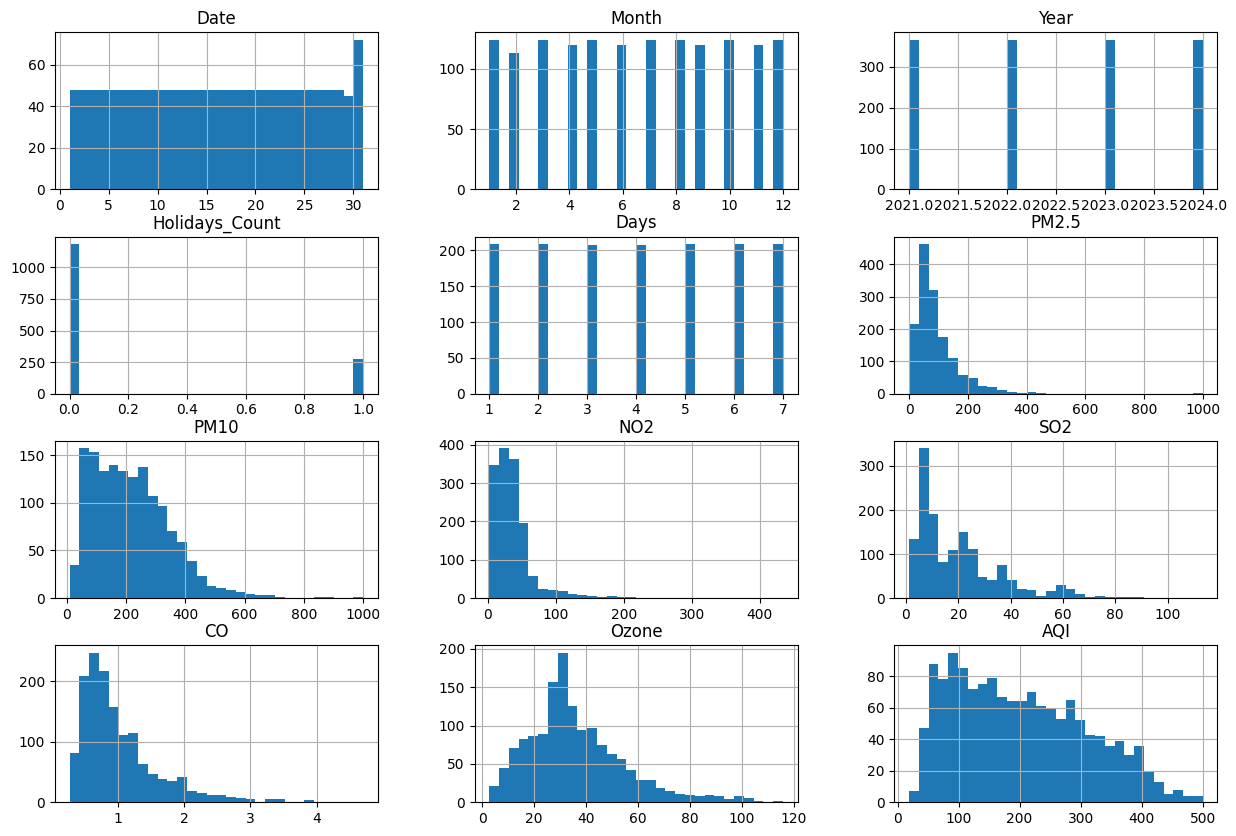

In [7]:
import matplotlib.pyplot as plt
df.hist(figsize=(15 , 10) , bins = 30)
plt.show()

dataset has:

✅ No missing values        
✅ Complete daily records     
✅ Balanced time coverage         
⚠️ Strongly skewed pollutant distributions     
⚠️ Extreme values in PM2.5 and PM10        
🎯 AQI has a wide prediction range     

In [8]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']

for col in pollutants:
  print(f"\n{col}")
  print("Maximum:" , df[col].max())
  print("cout of maximum values:", (df[col] == df[col].max()).sum())


PM2.5
Maximum: 1000.0
cout of maximum values: 1

PM10
Maximum: 1000.0
cout of maximum values: 1

NO2
Maximum: 433.98
cout of maximum values: 1

SO2
Maximum: 113.4
cout of maximum values: 1

CO
Maximum: 4.7
cout of maximum values: 1

Ozone
Maximum: 115.87
cout of maximum values: 1


In [9]:
print("PM2.5 = 1000:" , (df['PM2.5'] == 1000).sum())
print("PM10 = 1000:" , (df['PM10'] == 1000).sum())
print("AQI = 500:" , (df['AQI'] == 1000).sum())

PM2.5 = 1000: 1
PM10 = 1000: 1
AQI = 500: 0


In [10]:
print("Shape:", df.shape)

df.info()

df.describe().T

df.isnull().sum()

print("Duplicate rows : " , df.duplicated().sum())

Shape: (1461, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB
Duplicate rows :  0


In [11]:
df[(df["PM2.5"] == 1000) | df["PM10"] == 1000]


df.loc[
    (df["PM2.5"] == 1000) | (df["PM10"]==1000)
]

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
736,7,1,2023,0,6,200.6,1000.0,13.16,15.77,1.15,41.66,500
1275,29,6,2024,0,6,1000.0,391.0,52.22,35.74,1.23,28.38,192


Normally, if PM2.5 were truly 1000, the AQI should be extremely high (often close to the top of the scale), not around 192.

This makes that single PM2.5 = 1000 value look suspicious. It could be:

a sensor error,
a data entry mistake,
or a capped/placeholder value in the source data.

In [12]:
# correlation of columns with AQI


df.corr(numeric_only=True)["AQI"].sort_values(ascending = False)

,AQI
AQI,1.000000
PM10,0.899421
PM2.5,0.801960
CO,0.696809
NO2,0.319261
SO2,0.036288
Days,0.002113
Holidays_Count,0.000447
Date,-0.001057
Month,-0.034169


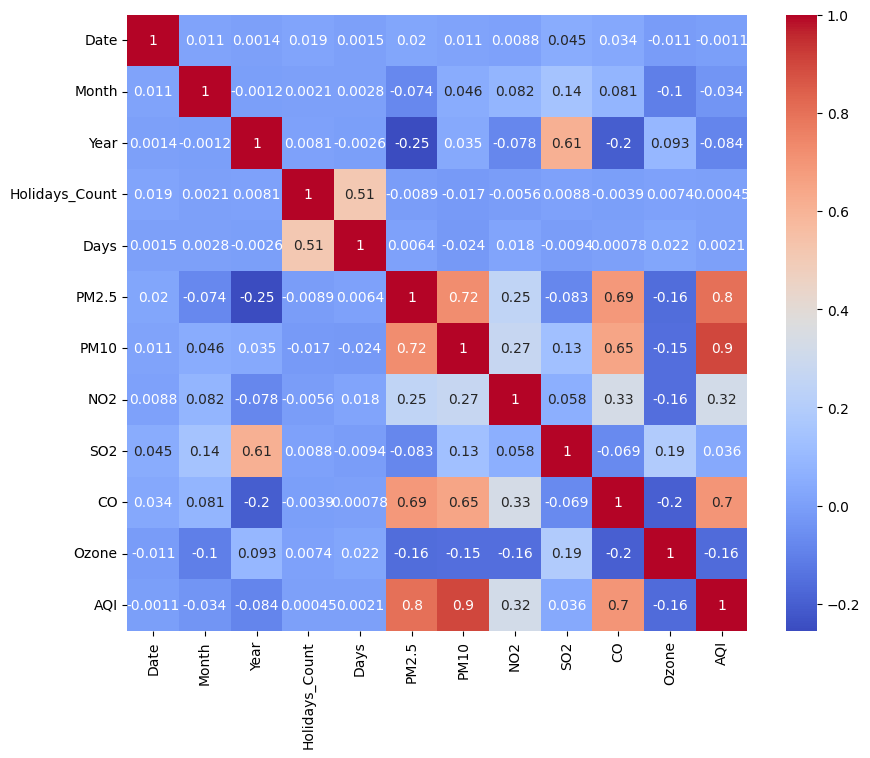

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(numeric_only = True),annot = True, cmap = "coolwarm")

plt.show()

...

# Data Preprocessing     

We'll now prepare the data for model training.

In [14]:
X =df.drop('AQI' , axis = 1)
y = df['AQI']

In [15]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)


# Feature scaling

Since we plan to build a Neural Network for this Phase 5 project, scaling is important.


Why do we use scaling here?  

Your actual ranges

Feature   ----- Range    
PM2.5  --     0.05 → 1000         
PM10     ---   9.7 → 1000       
NO2     ---    2 → 434       
C0       ---   0.27 → 4.7         
Month     ----   1 → 12       


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

...

# Convert Data into PyTorch Tensors

PyTorch does not understand NumPy arrays directly for training.

In [17]:
import torch

X_train_tensor = torch.tensor(X_train_scaled , dtype = torch.float32)

X_test_tensor = torch.tensor(X_test_scaled , dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32).reshape(-1,1)

y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).reshape(-1,1)

# Why reshape?

Before:

[120,130,150]

Shape:

(1168,)

Neural network wants:

(1168,1)

# Create DataLoader

Instead of feeding all data at once, we use batches.

In [18]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor , y_train_tensor)

test_dataset = TensorDataset(X_test_tensor , y_test_tensor)


train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False
)


# Build Neural Network

In [19]:
# addded new architecture for  model improvement

import torch.nn as nn

class AQI_Model(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(

        nn.Linear(11,128),
        nn.ReLU(),

        nn.Linear(128,64),
        nn.ReLU(),

        nn.Linear(64,32),
        nn.ReLU(),

        nn.Linear(32,1)
        )

  def forward(self,x):
    return self.network(x)



# Create Model Object

In [20]:
model = AQI_Model()

model

AQI_Model(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

**Loss Function**

In [21]:
criterion = nn.MSELoss()

**Optimizer**

In [22]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

Adam updates the weights.

model.parameters() means:

"Give me all learnable weights."

# **MAIN TRAINING LOOP**

In [23]:
epochs = 100

for epoch in range(epochs):
    model.train()
    total_loss = 0


    for X_batch, y_batch in train_loader:

        # Forward pass
        predictions = model(X_batch)


        # Loss
        loss = criterion(predictions, y_batch)


        # Clear old gradients
        optimizer.zero_grad()


        # Backpropagation
        loss.backward()


        # Update weights
        optimizer.step()


        total_loss += loss.item()


    if (epoch+1) % 10 == 0:
        avg_loss = total_loss / len(train_loader)
        print(
            f"Epoch {epoch+1}, Loss: {avg_loss:.4f}"
        )

Epoch 10, Loss: 2107.5582
Epoch 20, Loss: 1407.2491
Epoch 30, Loss: 1062.6356
Epoch 40, Loss: 897.3998
Epoch 50, Loss: 791.0618
Epoch 60, Loss: 733.6004
Epoch 70, Loss: 707.7901
Epoch 80, Loss: 654.8651
Epoch 90, Loss: 619.7141
Epoch 100, Loss: 611.6519


...

# PREDICT ON TEST DATA

In [24]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

  for X_batch , y_batch in test_loader:
    outputs = model(X_batch)

    predictions.extend(outputs.numpy())
    actuals.extend(y_batch.numpy())



In [25]:
import numpy as np
predictions = np.array(predictions)
actuals = np.array(actuals)

print(predictions.shape)
print(actuals.shape)

(293, 1)
(293, 1)


....

# EVALUATION OF THE MODEL

In [26]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

mae = mean_absolute_error(actuals, predictions
                          )
mse = mean_squared_error(actuals, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(actuals, predictions)



print(f"mae :{mae:.2f}" )
print(f"mse :{mse:.2f}" )
print(f"rmse :{rmse:.2f}")
print(f"r2 :{r2:.4f}")

mae :20.29
mse :783.61
rmse :27.99
r2 :0.9396


------------------------

"""""""""""""""""""""""""""""""""""""""

--------------------------

# 0.93 is already good but i'll try to improve the model

# Increase Neural Network Capacity        
**Step 1 — Change Model Architecture**         

We will replace the existing small network with a deeper network containing more neurons. This gives the PyTorch model more capacity to learn complex AQI patterns.      
         
`nn.Linear(11,64)`        

to:        

`nn.Linear(11,128) `       

--------

**Step 2 — Initialize New Model**      

We create a fresh model because the previous model has already learned old weights. A new architecture requires training from the      beginning.        

`model = AQI_Model() `        

_____________

**Step 3 — Define Optimizer Again**  

We create a new optimizer connected to the new model parameters so it can update the new network weights.   

`optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)`    

_________

**compare evaluations**

# AFTER CHANGING ARCHITECTURE SLIGHLY IMPROVED THE MODEL
mae :21.35      
mse :863.92        
rmse :29.39       
r2 :0.9334    

----------

# Add Batch Normalization         
What we are changing   

We will add Batch Normalization layers between Linear and ReLU layers. This helps stabilize the values flowing through the network and can make training faster and more consistent.      

# batchnorm make this model worse
MAE  = 24.53    
RMSE = 33.28      
R²   = 0.9147  

In [27]:
# Save final AQI PyTorch model

torch.save(
    model.state_dict(),
    "aqi_model.pth"
)

print("Model saved successfully!")

Model saved successfully!


In [28]:
import joblib

# Save feature scaler

joblib.dump(
    scaler,
    "X_scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!
